In [86]:
import numpy as np
from scipy.integrate import quad
from scipy.stats import poisson,norm 
import matplotlib.pyplot as plt

Simple model for a flat background and exponential signal

In [127]:
def bkg_model(x):
    return 1.0
def sig_model(x):
    return np.exp(-x/3.)

Find the bin-by-bin expectation for signal and background

Have a function that samples accoridng to a Poisson distribution for signal + background, including systematic Gaussian smearing with 50% uncertinaty on the background

This can give negative background expectation, so we should be careful

In [139]:
x_bkg = np.array([quad(bkg_model,xl,xu)[0] for xl,xu in zip(np.linspace(0,6,3),np.linspace(3,9,3))])
x_sig = np.array([quad(sig_model,xl,xu)[0] for xl,xu in zip(np.linspace(0,6,3),np.linspace(3,9,3))])
def sample(a,b):
    x_samp = np.array([poisson.rvs(a*norm.rvs(xb,scale=0.5*xb)+b*xs) for xb,xs in zip(x_bkg,x_sig)])
    return x_samp
x = sample(2./3.,750)

Here, I solved manually in Mathematica for the two-bin case taking only the two upper bins (sideband) to minimize chi^2

In [140]:
def a_sol(x):
    return (x[2]*x_sig[1] - x[1]*x_sig[2])/(x_bkg[2]*x_sig[1]-x_bkg[1]*x_sig[2])
def b_sol(x):
    return (x[2]*x_bkg[1] - x[1]*x_bkg[2])/(x_bkg[1]*x_sig[2]-x_bkg[2]*x_sig[1])

Here is the definition of chi^2 I used

In [253]:
def chi2(x,a,b):
    return sum(np.square(x[1:] - a * x_bkg[1:] - b * x_sig[1:]) / ((0.5 * (2./3.) * x_bkg[1:])**2 + x[1:]))

Print out the fit values for a and b for reference

In [254]:
a_sol(x)

np.float64(8.111050330372242)

In [255]:
b_sol(x)

np.float64(696.164337592162)

For fun, let's construct a chi^2 = 0.1 (95% p-value) contour

In [256]:
grid_size = 200
a_list = np.linspace(0,1000,grid_size)
b_list = np.linspace(1,1000,grid_size)
chi_list = []
for a in a_list:
    for b in b_list:
        chi_list.append(chi2(x,a,b))
chi_list = np.array(chi_list)
chi_list = np.transpose(chi_list.reshape(grid_size,grid_size))

Text(0, 0.5, 'b')

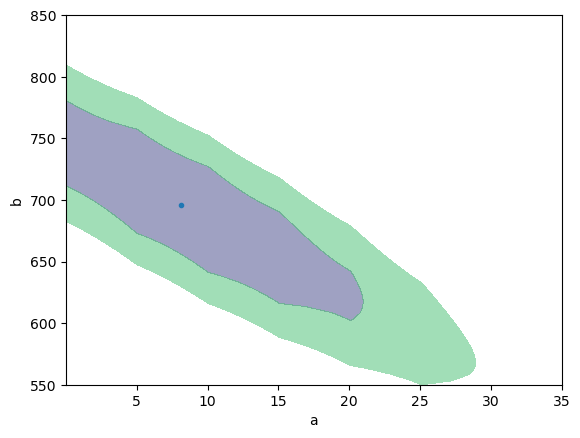

In [257]:
plt.contourf(a_list,b_list,chi_list,levels=[0,2.41,5.99],alpha=0.5)
plt.plot([a_sol(x)],[b_sol(x)],ls='',marker='.')
plt.xlim(0.01,35)
plt.ylim(550,850)
plt.xlabel('a')
plt.ylabel('b')

Predict the signal box

In [258]:
a_sol(x) * x_bkg[0] + b_sol(x) * x_sig[0]

np.float64(1344.5125213369272)

Actual value

In [259]:
x[0]

np.int64(1426)

Range of predictions

In [260]:
pred_list = []
for a in a_list:
    for b in b_list:
        if chi2(x,a,b) < 5.99:
            pred_list.append(a*x_bkg[0] + b*x_sig[0])
print('Min: ',min(pred_list))
print('Max: ',max(pred_list))

Min:  1124.4651286564385
Max:  1534.6044806929638
